In [1]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np


os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

import utils.paths as paths
import matplotlib.pyplot as plt

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


Load result

In [4]:
from pprint import pprint

# file = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/analysis_results/icm_sampling_tdrop_sweep/2026-02-12_17:54:28_exact-tub/results.npz"
sweep_name = "chartreuse-neuron"
sweep_parent = paths.ANALYSIS_PARENT / "icm_sampling_tdrop_sweep"
sweep_dir = sorted(sweep_parent.glob(f"*{sweep_name}/"))[-1]
print(f"Loading results from {sweep_dir.name}")

results = np.load(str(sweep_dir / "results.npz"), allow_pickle=True)
pprint(results.files)

baseline_diffs = results["baseline_diffs"]
overlap_diffs = results["overlap_diffs"]
t_drop_values = results["t_drop_values"]

Loading results from 2026-02-17_13:03:10_chartreuse-neuron
['samples',
 'original',
 'ctxt_red',
 'ext_ctxt_red',
 'seed_noise_map',
 'baseline_diffs',
 'overlap_diffs',
 'parameters',
 'baseline_intermediates',
 'intermediates_list',
 't_drop_values',
 'replaced_intermediate_images']


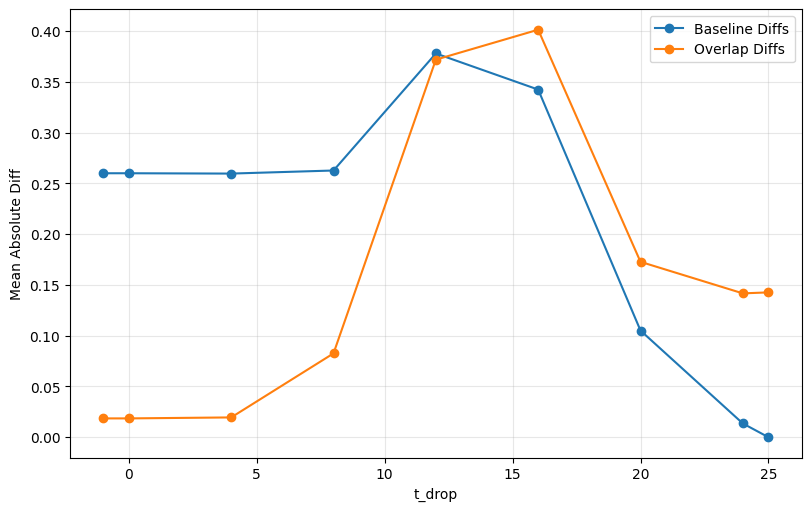

In [5]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(
    t_drop_values,
    np.nanmean(np.abs(baseline_diffs), axis=(1, 2, 3, 4)),
    label="Baseline Diffs",
    marker="o",
)
ax.plot(
    t_drop_values,
    np.nanmean(np.abs(overlap_diffs), axis=(1, 2, 3, 4)),
    label="Overlap Diffs",
    marker="o",
)

ax.set_xlabel("t_drop")
ax.set_ylabel("Mean Absolute Diff")

ax.legend()
ax.grid(alpha=0.3)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

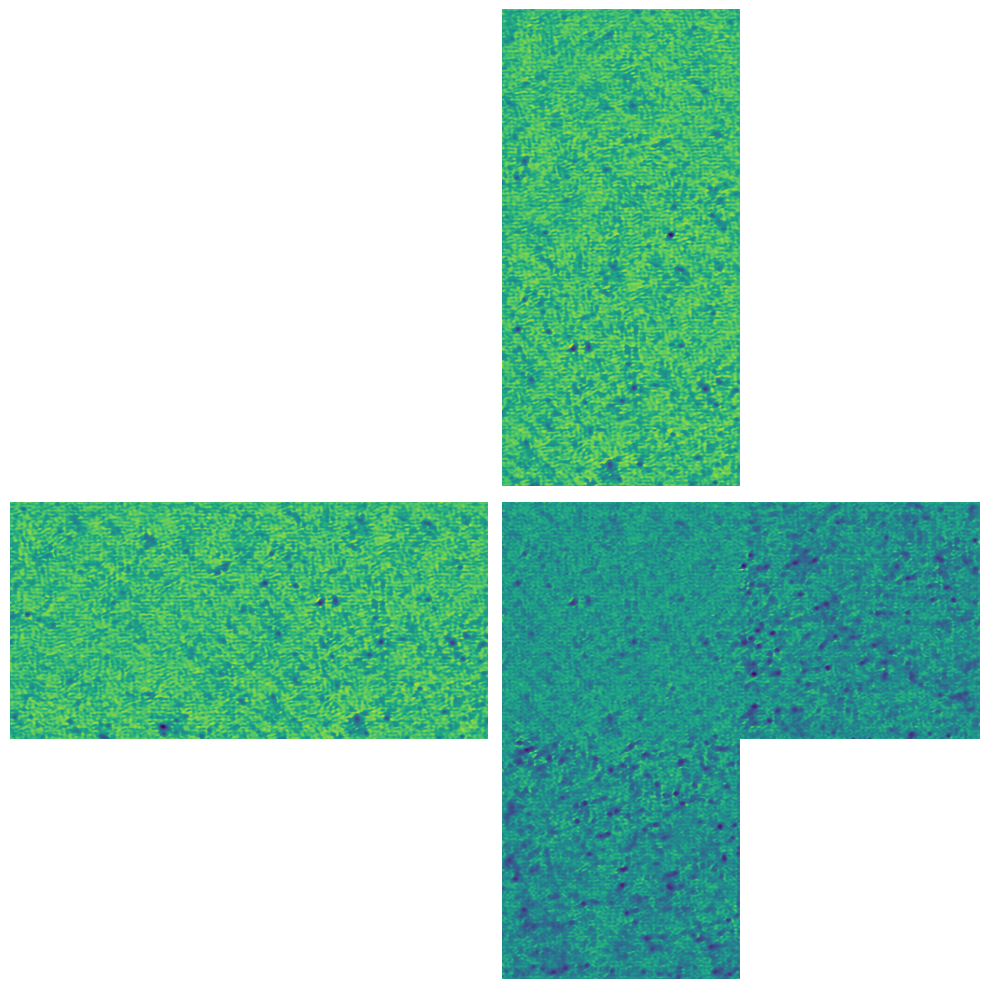

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(overlap_diffs[-1, :, 0])

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

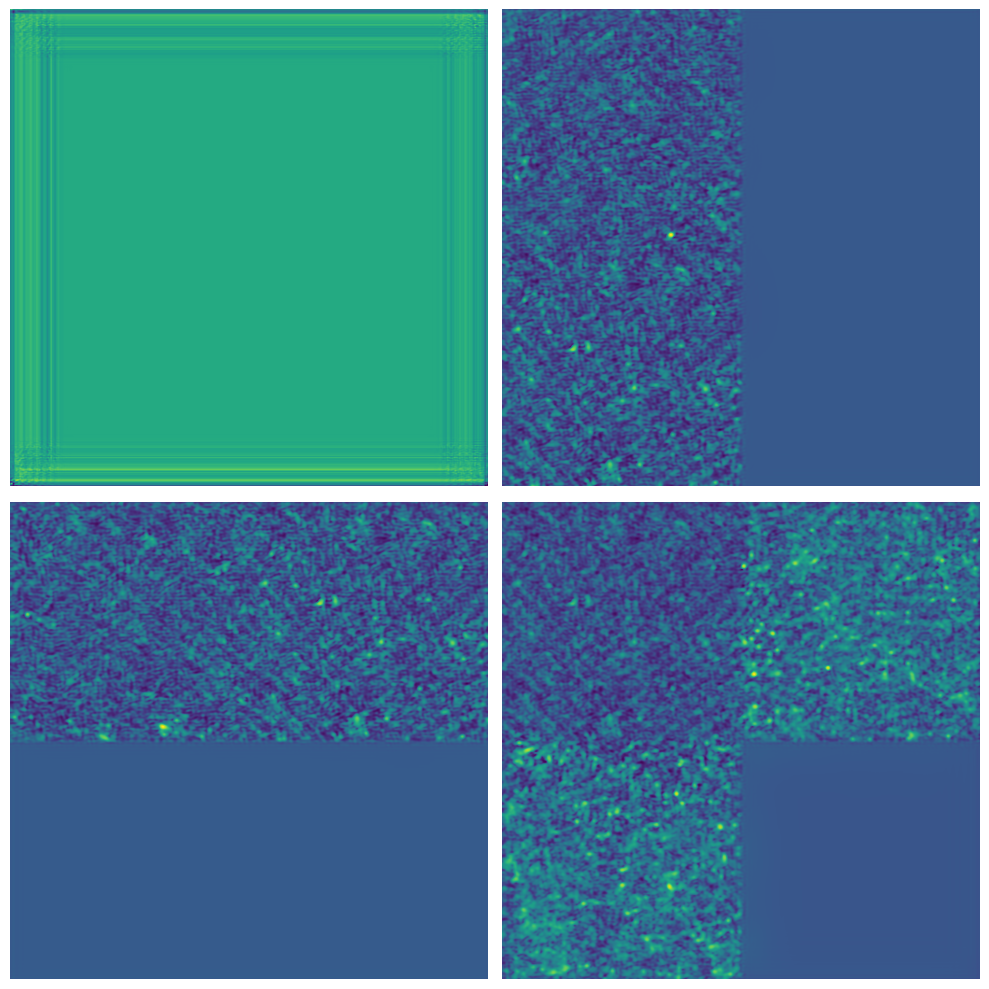

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(results["decoded_inpainting_ctxts"][-1, :, 0])

In [15]:
pprint(list(results["intermediates_list"][-1].keys()))

['encodings',
 'encoding_time_steps',
 'mask_image_latent',
 'context',
 'ext_context',
 'sampling_masks',
 'sampling_indices',
 'seed_noise',
 'decoded_images']


(<Figure size 2000x500 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

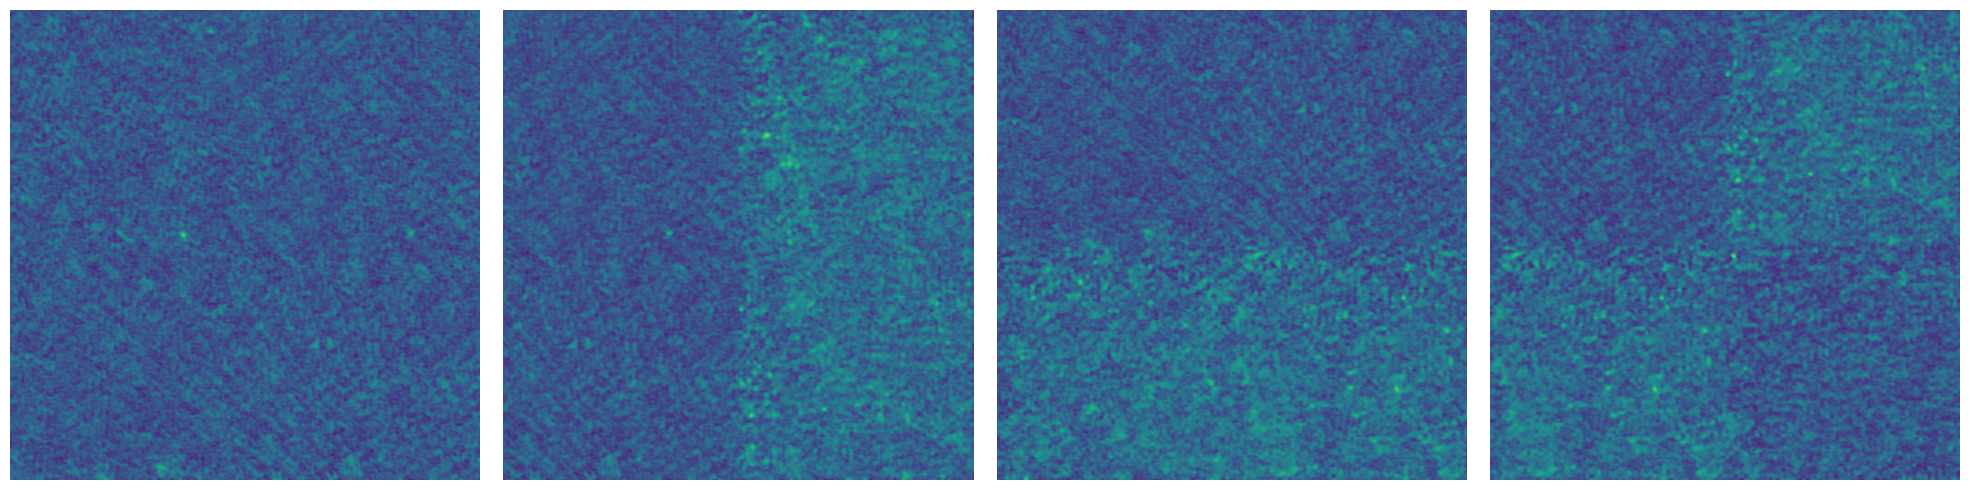

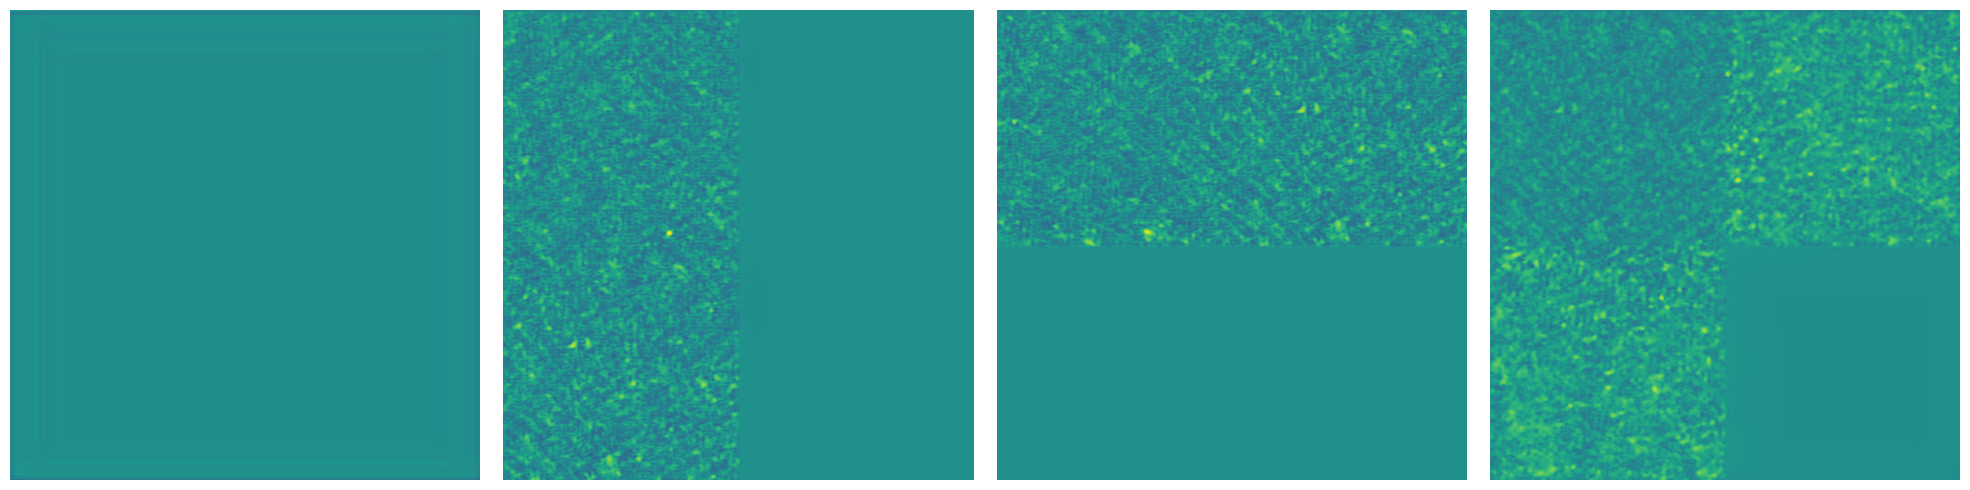

In [ ]:
from plotting.images import plot_image_grid

decoded_steps = results["intermediates_list"][-1]["decoded_images"][:, 0].squeeze()
decoded_ctxts = results["decoded_inpainting_ctxts"][-1, :, 0]
vmax = max(decoded_steps.max(), decoded_ctxts.max())
vmin = min(decoded_steps.min(), decoded_ctxts.min())

plot_image_grid(decoded_steps, vmin=vmin, vmax=vmax, n_rows=1)
plot_image_grid(decoded_ctxts, vmin=-vmax, vmax=vmax, n_rows=1)

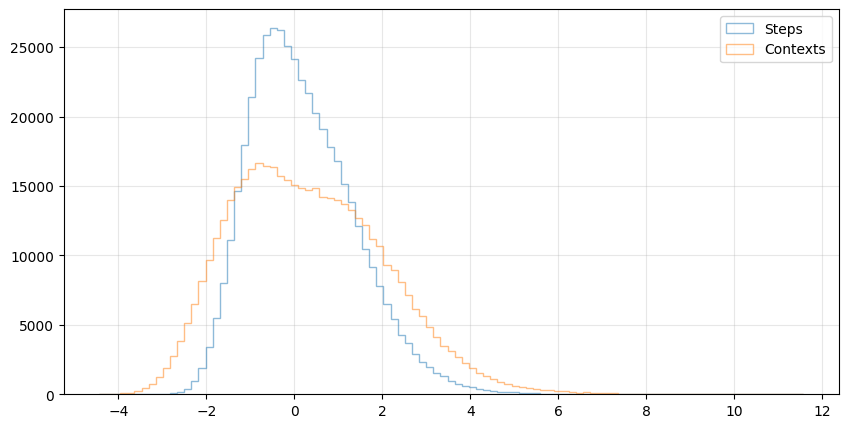

In [ ]:
sampling_masks = results["intermediates_list"][-1]["sampling_masks"][:, 0]
sampling_masks = (
    torch.nn.functional.interpolate(sampling_masks, scale_factor=4, mode="nearest")
    .squeeze()
    .numpy()
)
decoded_steps_masked = decoded_steps.numpy()
decoded_steps_masked[sampling_masks.astype(bool)] = np.nan
ctxts_masked = decoded_ctxts.copy()
ctxts_masked[sampling_masks.astype(bool)] = np.nan

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(vmin, vmax, 100)
hkw = dict(
    bins=bins,
    alpha=0.5,
    histtype="step",
)
ax.hist(decoded_steps_masked.flatten(), **hkw, label="Steps")
ax.hist(ctxts_masked.flatten(), **hkw, label="Contexts")
ax.legend()
ax.grid(alpha=0.3)

fig.show()